In [70]:
import pandas as pd
import os
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

exp1a_path = os.path.join(
    BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/quantitative/exp1a.csv"
)
exp1b_path = os.path.join(
    BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/quantitative/exp1b.csv"
)

output_dir_exp1a = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/tables/exp1a"
)
output_dir_exp1b = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/tables/exp1b"
)
output_plot_dir_exp1a = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/plots/exp1a"
)
output_plot_dir_exp1b = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/plots/exp1b"
)

tables = {}
plots = {}

for path in [output_dir_exp1a, output_dir_exp1b, output_plot_dir_exp1a, output_plot_dir_exp1b]:
    os.makedirs(path, exist_ok=True)

if not os.path.exists(exp1a_path) or not os.path.exists(exp1b_path):
    print("Error: Quantitative data files not found.")
    print(f"Looked for {exp1a_path} and {exp1b_path}")
else:
    exp1a_df = pd.read_csv(exp1a_path)
    exp1b_df = pd.read_csv(exp1b_path)

    # Combine adherence scores into a single metric
    exp1a_df["adherence_score"] = exp1a_df[
        ["adherence_score_openai", "adherence_score_anthropic"]
    ].mean(axis=1)
    exp1b_df["adherence_score"] = exp1b_df[
        ["adherence_score_openai", "adherence_score_anthropic"]
    ].mean(axis=1)

    # Drop original adherence scores
    exp1a_df = exp1a_df.drop(
        columns=["adherence_score_openai", "adherence_score_anthropic"]
    )
    exp1b_df = exp1b_df.drop(
        columns=["adherence_score_openai", "adherence_score_anthropic"]
    )
    print("Data loaded and preprocessed for exp1a and exp1b.")

Data loaded and preprocessed for exp1a and exp1b.


## Experiment 1a

### 1.1: Metrics by LLM

In [71]:
llm_metrics_1a = exp1a_df.groupby("llm")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1a_metrics_by_llm"] = llm_metrics_1a
display(llm_metrics_1a)

cosine_similarity           adherence_score          
                       mean       std            mean       std
llm                                                            
anthropic          0.578823  0.136459        0.935238  0.110993
deepseek           0.490059  0.142076        0.958690  0.049879
google             0.634277  0.142834        0.940714  0.079300
openai             0.543139  0.154746        0.965833  0.083731

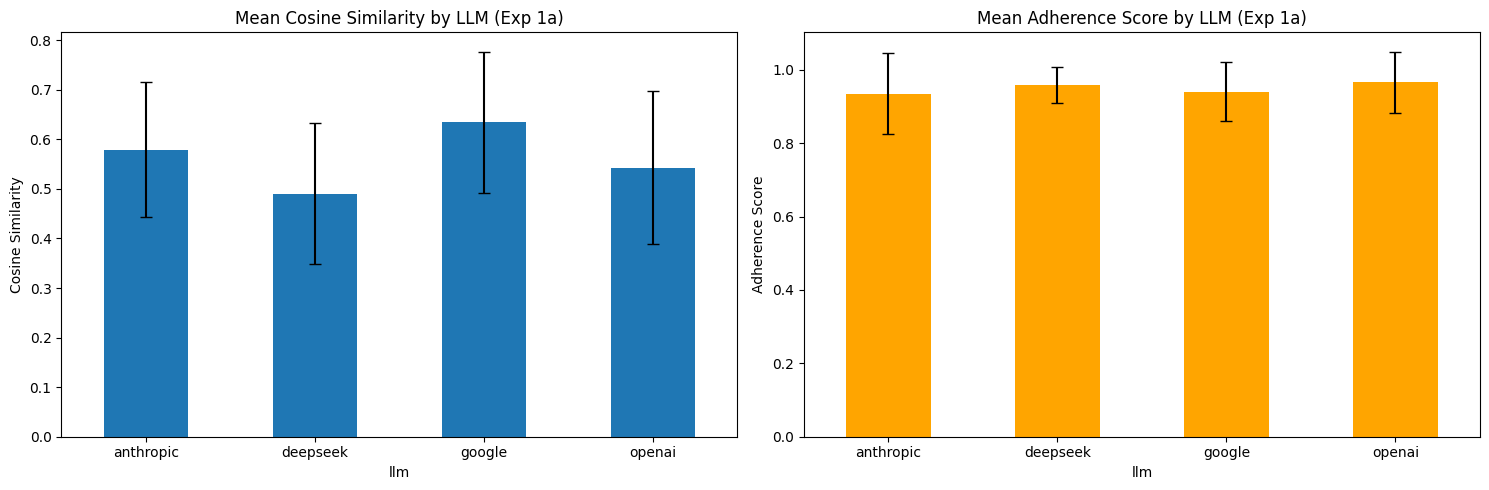

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plots['exp1a_metrics_by_llm'] = fig
llm_metrics_1a[('cosine_similarity', 'mean')].plot(kind='bar', yerr=llm_metrics_1a[('cosine_similarity', 'std')], ax=ax[0], capsize=4)
ax[0].set_title('Mean Cosine Similarity by LLM (Exp 1a)')
ax[0].set_ylabel('Cosine Similarity')
ax[0].tick_params(axis='x', rotation=0)
llm_metrics_1a[('adherence_score', 'mean')].plot(kind='bar', yerr=llm_metrics_1a[('adherence_score', 'std')], ax=ax[1], capsize=4, color='orange')
ax[1].set_title('Mean Adherence Score by LLM (Exp 1a)')
ax[1].set_ylabel('Adherence Score')
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 1.2: Metrics by Input Source

In [73]:
input_source_metrics_1a = exp1a_df.groupby("input_source")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1a_metrics_by_input_source"] = input_source_metrics_1a
display(input_source_metrics_1a)

cosine_similarity           adherence_score          
                          mean       std            mean       std
input_source                                                      
script                0.637166  0.107065        0.947054  0.075364
tanenbaum             0.551117  0.131404        0.951696  0.092713
transcript            0.496441  0.177308        0.951607  0.084521

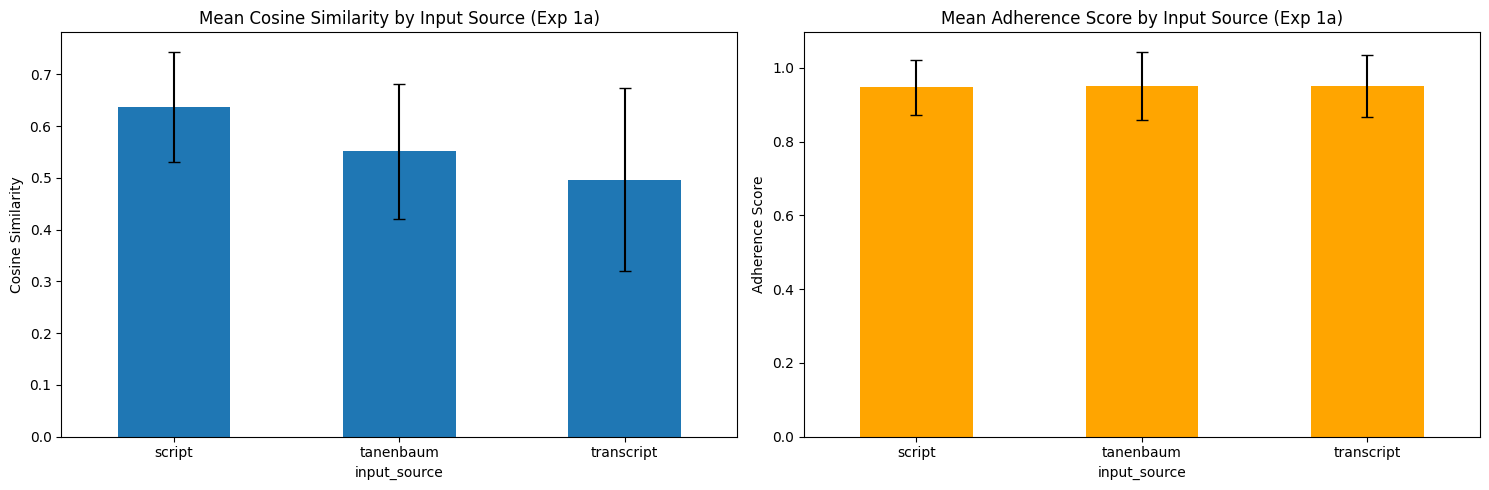

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plots['exp1a_metrics_by_input_source'] = fig
input_source_metrics_1a[('cosine_similarity', 'mean')].plot(kind='bar', yerr=input_source_metrics_1a[('cosine_similarity', 'std')], ax=ax[0], capsize=4)
ax[0].set_title('Mean Cosine Similarity by Input Source (Exp 1a)')
ax[0].set_ylabel('Cosine Similarity')
ax[0].tick_params(axis='x', rotation=0)
input_source_metrics_1a[('adherence_score', 'mean')].plot(kind='bar', yerr=input_source_metrics_1a[('adherence_score', 'std')], ax=ax[1], capsize=4, color='orange')
ax[1].set_title('Mean Adherence Score by Input Source (Exp 1a)')
ax[1].set_ylabel('Adherence Score')
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 1.3: Metrics by Prompt Type

In [75]:
prompt_type_metrics_1a = exp1a_df.groupby("prompt_type")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1a_metrics_by_prompt_type"] = prompt_type_metrics_1a
display(prompt_type_metrics_1a)

cosine_similarity           adherence_score          
                         mean       std            mean       std
prompt_type                                                      
common               0.539460  0.166316        0.978571  0.055077
complex              0.583689  0.134205        0.921667  0.097626

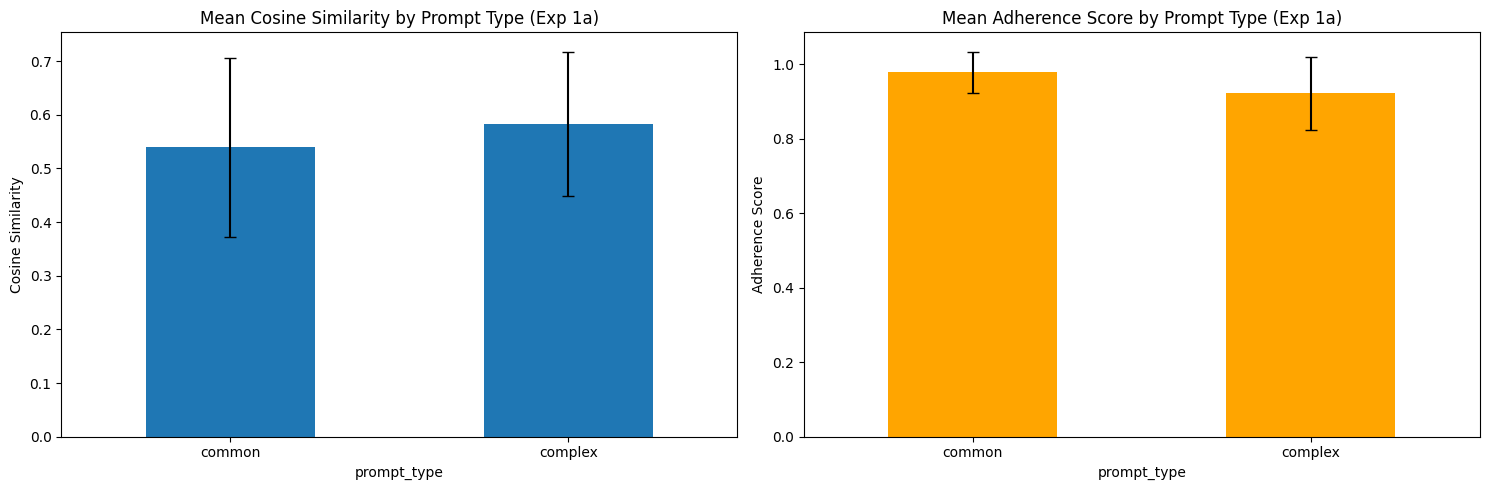

In [76]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plots['exp1a_metrics_by_prompt_type'] = fig
prompt_type_metrics_1a[("cosine_similarity", "mean")].plot(kind='bar', yerr=prompt_type_metrics_1a[("cosine_similarity", "std")], ax=ax[0], capsize=4)
ax[0].set_title("Mean Cosine Similarity by Prompt Type (Exp 1a)")
ax[0].set_ylabel("Cosine Similarity")
ax[0].tick_params(axis='x', rotation=0)
prompt_type_metrics_1a[("adherence_score", "mean")].plot(kind='bar', yerr=prompt_type_metrics_1a[("adherence_score", "std")], ax=ax[1], capsize=4, color="orange")
ax[1].set_title("Mean Adherence Score by Prompt Type (Exp 1a)")
ax[1].set_ylabel("Adherence Score")
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 1.4: Metrics by Layer

In [77]:
layer_metrics_1a = exp1a_df.groupby("layer")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1a_metrics_by_layer"] = layer_metrics_1a
display(layer_metrics_1a)

cosine_similarity           adherence_score          
                   mean       std            mean       std
layer                                                      
1              0.544263  0.136847        0.953333  0.089475
2              0.541102  0.188342        0.965000  0.047204
3              0.506294  0.180749        0.952708  0.062171
4              0.516466  0.191584        0.942083  0.085197
5              0.570953  0.096305        0.964375  0.050440
6              0.584212  0.083876        0.958750  0.085214
7              0.667732  0.100277        0.914583  0.134786

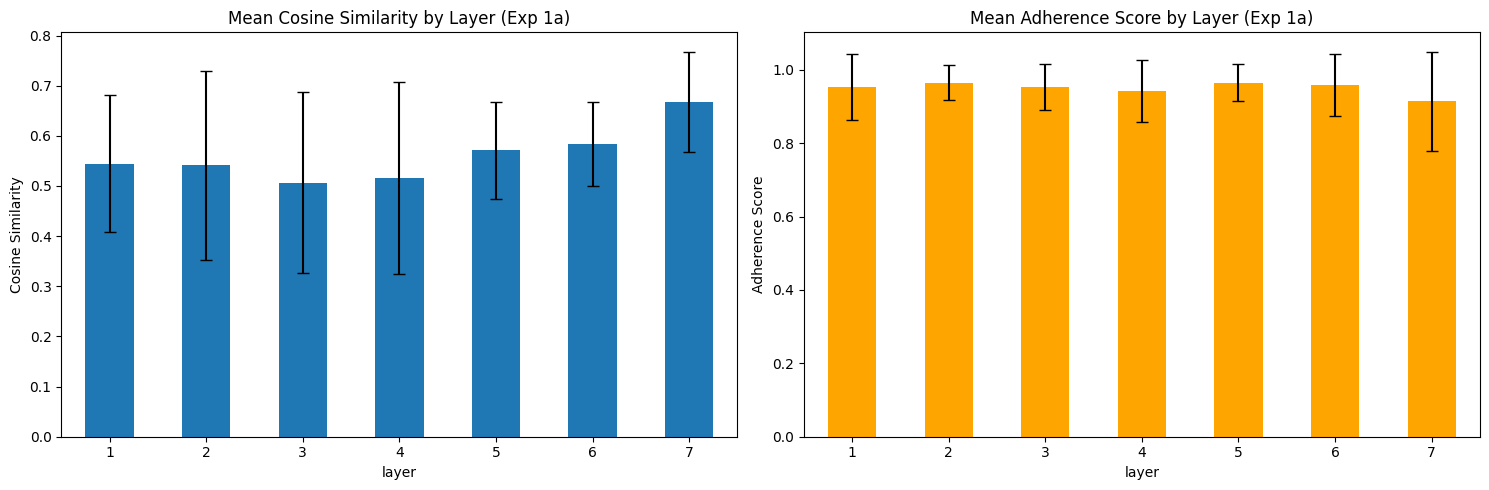

In [78]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plots['exp1a_metrics_by_layer'] = fig
layer_metrics_1a[("cosine_similarity", "mean")].plot(kind='bar', yerr=layer_metrics_1a[("cosine_similarity", "std")], ax=ax[0], capsize=4)
ax[0].set_title("Mean Cosine Similarity by Layer (Exp 1a)")
ax[0].set_ylabel("Cosine Similarity")
ax[0].tick_params(axis='x', rotation=0)
layer_metrics_1a[("adherence_score", "mean")].plot(kind='bar', yerr=layer_metrics_1a[("adherence_score", "std")], ax=ax[1], capsize=4, color="orange")
ax[1].set_title("Mean Adherence Score by Layer (Exp 1a)")
ax[1].set_ylabel("Adherence Score")
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 1.5: Cosine Similarity: LLM vs Input Source

In [79]:
llm_vs_input_source_cos_sim_1a = pd.pivot_table(
    exp1a_df,
    values="cosine_similarity",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1a_cosine_sim_llm_vs_input_source"] = llm_vs_input_source_cos_sim_1a
display(llm_vs_input_source_cos_sim_1a)

mean                            std                     
input_source    script tanenbaum transcript    script tanenbaum transcript
llm                                                                       
anthropic     0.665448  0.558400   0.512622  0.083972  0.127495   0.148904
deepseek      0.583646  0.487522   0.399008  0.115115  0.129716   0.123360
google        0.674851  0.618073   0.609906  0.126135  0.101522   0.188233
openai        0.624718  0.540471   0.464228  0.081499  0.142488   0.186273

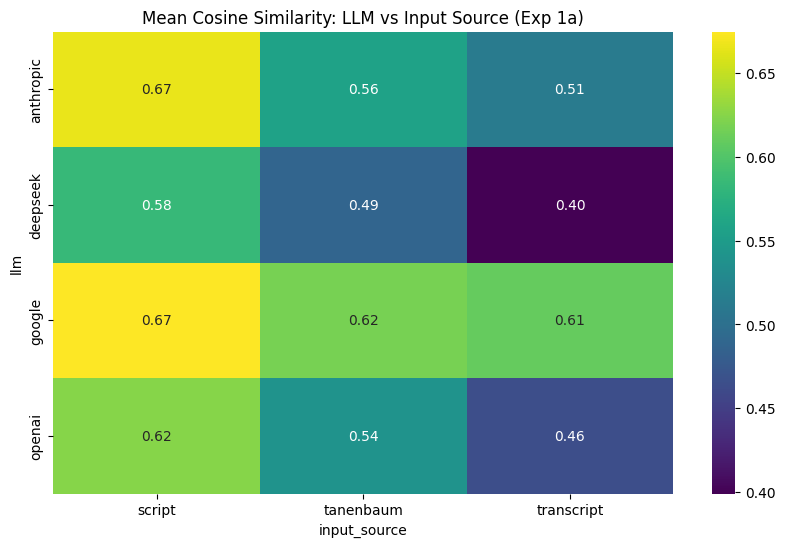

In [80]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1a_cosine_sim_llm_vs_input_source'] = fig
sns.heatmap(llm_vs_input_source_cos_sim_1a["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Cosine Similarity: LLM vs Input Source (Exp 1a)")
plt.show()


### 1.6: Cosine Similarity: LLM vs Prompt Type

In [81]:
llm_vs_prompt_type_cos_sim_1a = pd.pivot_table(
    exp1a_df,
    values="cosine_similarity",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1a_cosine_sim_llm_vs_prompt_type"] = llm_vs_prompt_type_cos_sim_1a
display(llm_vs_prompt_type_cos_sim_1a)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.583207  0.574440  0.166589  0.101888
deepseek     0.485833  0.494285  0.141371  0.146142
google       0.580096  0.688457  0.158760  0.102245
openai       0.508703  0.577575  0.184646  0.111829

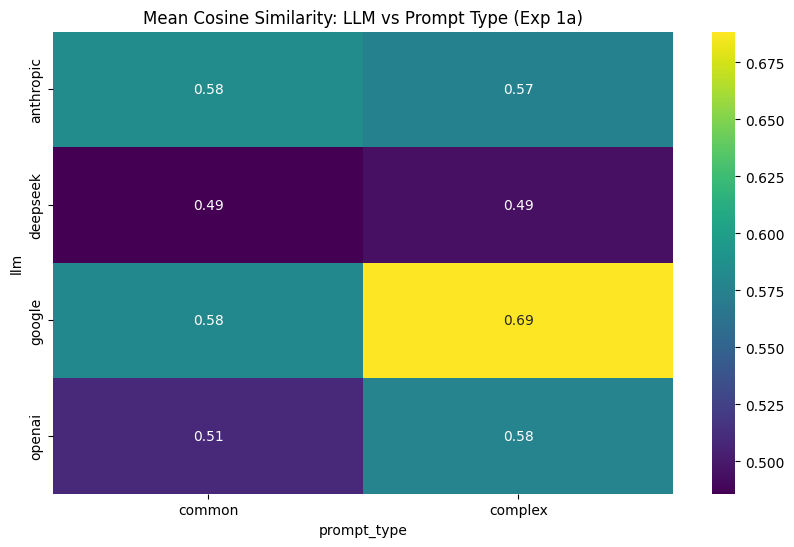

In [82]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1a_cosine_sim_llm_vs_prompt_type'] = fig
sns.heatmap(llm_vs_prompt_type_cos_sim_1a["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Cosine Similarity: LLM vs Prompt Type (Exp 1a)")
plt.show()


### 1.7: Adherence Score: LLM vs Prompt Type

In [83]:
llm_vs_prompt_type_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1a_adherence_llm_vs_prompt_type"] = llm_vs_prompt_type_adherence_1a
display(llm_vs_prompt_type_adherence_1a)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.972619  0.897857  0.093843  0.116249
deepseek     0.972619  0.944762  0.036797  0.057781
google       0.977381  0.904048  0.043778  0.090286
openai       0.991667  0.940000  0.015995  0.112761

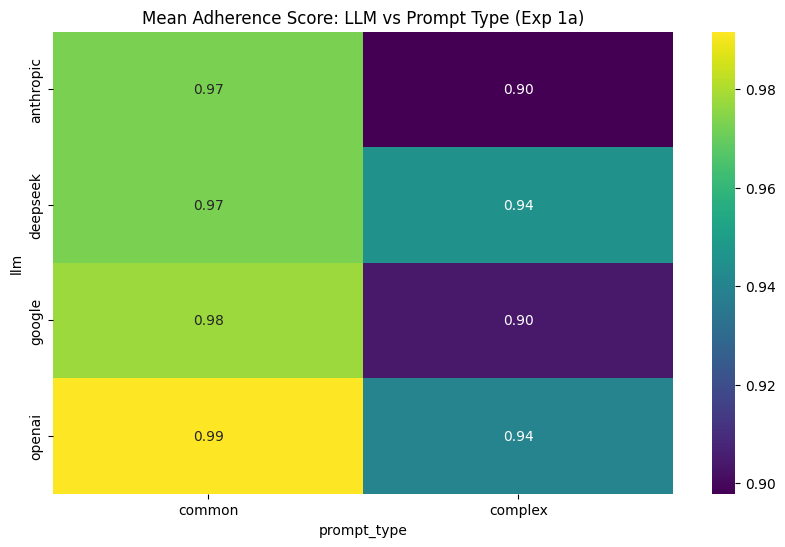

In [84]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1a_adherence_llm_vs_prompt_type'] = fig
sns.heatmap(llm_vs_prompt_type_adherence_1a["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Adherence Score: LLM vs Prompt Type (Exp 1a)")
plt.show()


### 1.8: Adherence Score: LLM vs Input Source

In [85]:
llm_vs_input_source_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1a_adherence_llm_vs_input_source"] = llm_vs_input_source_adherence_1a
display(llm_vs_input_source_adherence_1a)

mean                            std                     
input_source    script tanenbaum transcript    script tanenbaum transcript
llm                                                                       
anthropic     0.914286  0.946429   0.945000  0.115806  0.111017   0.111390
deepseek      0.944286  0.965714   0.966071  0.066762  0.043847   0.033637
google        0.952857  0.948571   0.920714  0.051168  0.054647   0.116501
openai        0.976786  0.946071   0.974643  0.037293  0.137284   0.035217

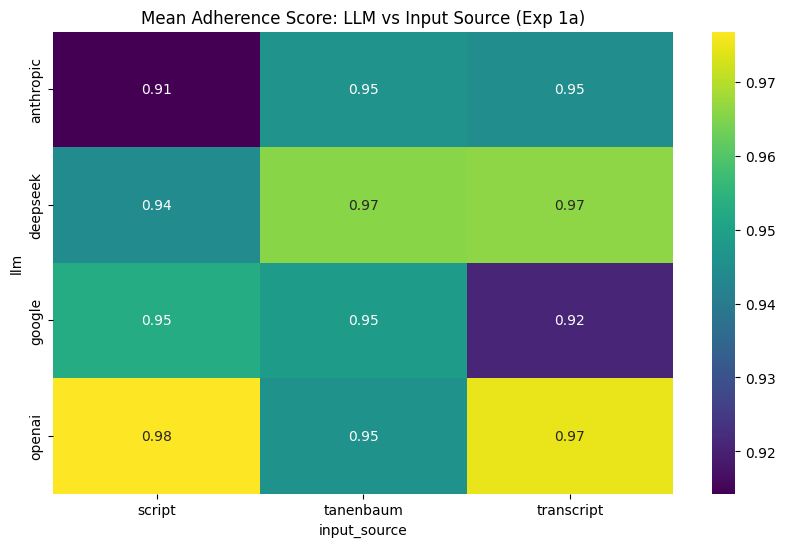

In [86]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1a_adherence_llm_vs_input_source'] = fig
sns.heatmap(llm_vs_input_source_adherence_1a["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Adherence Score: LLM vs Input Source (Exp 1a)")
plt.show()


## Experiment 1b

### 2.1: Metrics by LLM

In [87]:
llm_metrics_1b = exp1b_df.groupby("llm")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1b_metrics_by_llm"] = llm_metrics_1b
display(llm_metrics_1b)

cosine_similarity           adherence_score          
                       mean       std            mean       std
llm                                                            
anthropic          0.639624  0.120503        0.903571  0.123186
deepseek           0.535659  0.120614        0.731071  0.355929
google             0.618493  0.155956        0.920357  0.142942
openai             0.599776  0.107091        0.806071  0.358974

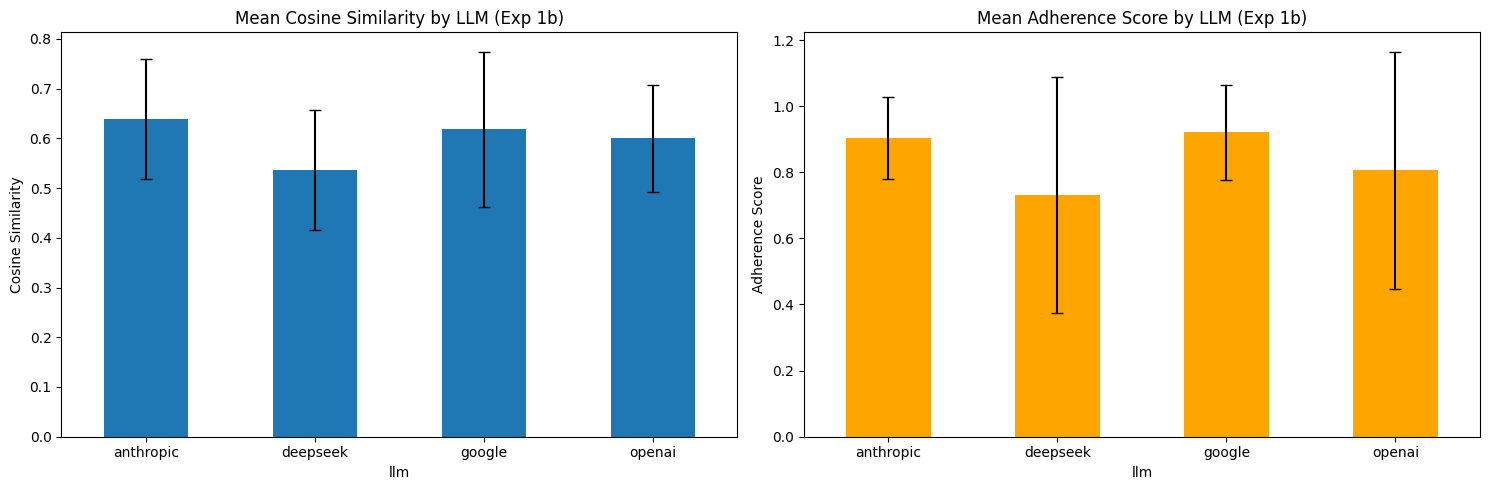

In [88]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plots['exp1b_metrics_by_llm'] = fig
llm_metrics_1b[("cosine_similarity", "mean")].plot(kind='bar', yerr=llm_metrics_1b[("cosine_similarity", "std")], ax=ax[0], capsize=4)
ax[0].set_title("Mean Cosine Similarity by LLM (Exp 1b)")
ax[0].set_ylabel("Cosine Similarity")
ax[0].tick_params(axis='x', rotation=0)
llm_metrics_1b[("adherence_score", "mean")].plot(kind='bar', yerr=llm_metrics_1b[("adherence_score", "std")], ax=ax[1], capsize=4, color="orange")
ax[1].set_title("Mean Adherence Score by LLM (Exp 1b)")
ax[1].set_ylabel("Adherence Score")
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 2.2: Metrics by Input Source

In [89]:
input_source_metrics_1b = exp1b_df.groupby("input_source")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1b_metrics_by_input_source"] = input_source_metrics_1b
display(input_source_metrics_1b)

cosine_similarity           adherence_score          
                                mean       std            mean       std
input_source                                                            
script_manipulated          0.598388  0.129878        0.840268  0.273503

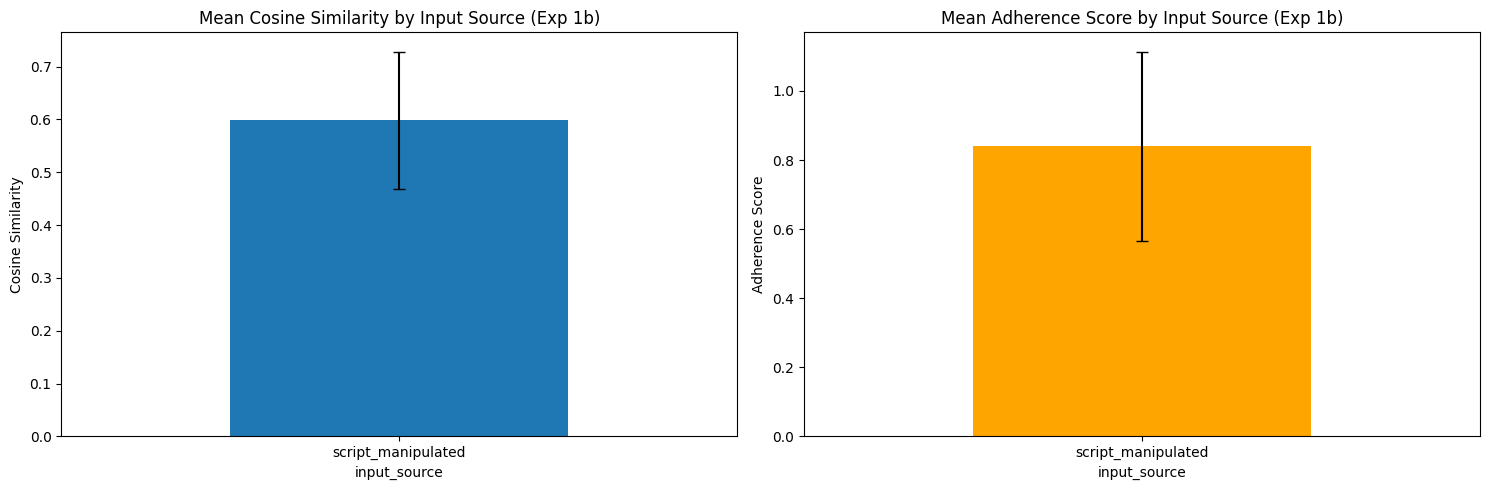

In [90]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plots['exp1b_metrics_by_input_source'] = fig
input_source_metrics_1b[("cosine_similarity", "mean")].plot(kind='bar', yerr=input_source_metrics_1b[("cosine_similarity", "std")], ax=ax[0], capsize=4)
ax[0].set_title("Mean Cosine Similarity by Input Source (Exp 1b)")
ax[0].set_ylabel("Cosine Similarity")
ax[0].tick_params(axis='x', rotation=0)
input_source_metrics_1b[("adherence_score", "mean")].plot(kind='bar', yerr=input_source_metrics_1b[("adherence_score", "std")], ax=ax[1], capsize=4, color="orange")
ax[1].set_title("Mean Adherence Score by Input Source (Exp 1b)")
ax[1].set_ylabel("Adherence Score")
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 2.3: Metrics by Prompt Type

In [91]:
prompt_type_metrics_1b = exp1b_df.groupby("prompt_type")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1b_metrics_by_prompt_type"] = prompt_type_metrics_1b
display(prompt_type_metrics_1b)

cosine_similarity           adherence_score          
                         mean       std            mean       std
prompt_type                                                      
common               0.621259  0.137741        0.951250  0.170368
complex              0.575516  0.119598        0.729286  0.312741

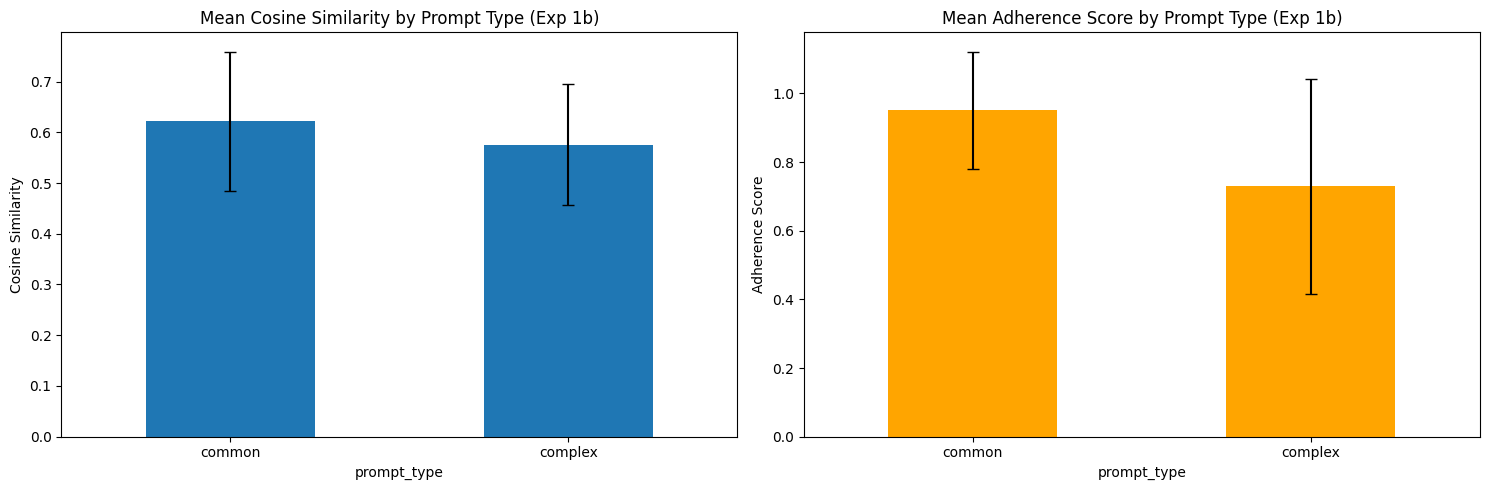

In [92]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plots['exp1b_metrics_by_prompt_type'] = fig
prompt_type_metrics_1b[("cosine_similarity", "mean")].plot(kind='bar', yerr=prompt_type_metrics_1b[("cosine_similarity", "std")], ax=ax[0], capsize=4)
ax[0].set_title("Mean Cosine Similarity by Prompt Type (Exp 1b)")
ax[0].set_ylabel("Cosine Similarity")
ax[0].tick_params(axis='x', rotation=0)
prompt_type_metrics_1b[("adherence_score", "mean")].plot(kind='bar', yerr=prompt_type_metrics_1b[("adherence_score", "std")], ax=ax[1], capsize=4, color="orange")
ax[1].set_title("Mean Adherence Score by Prompt Type (Exp 1b)")
ax[1].set_ylabel("Adherence Score")
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 2.4: Metrics by Layer

In [93]:
layer_metrics_1b = exp1b_df.groupby("layer")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1b_metrics_by_layer"] = layer_metrics_1b
display(layer_metrics_1b)

cosine_similarity           adherence_score          
                   mean       std            mean       std
layer                                                      
1              0.574804  0.096853        0.771875  0.385866
2              0.542807  0.150093        0.829375  0.311063
3              0.616298  0.103107        0.760625  0.273750
4              0.553682  0.110393        0.929375  0.082870
5              0.622286  0.137674        0.836250  0.326964
6              0.573622  0.083204        0.817500  0.334055
7              0.705217  0.175271        0.936875  0.093310

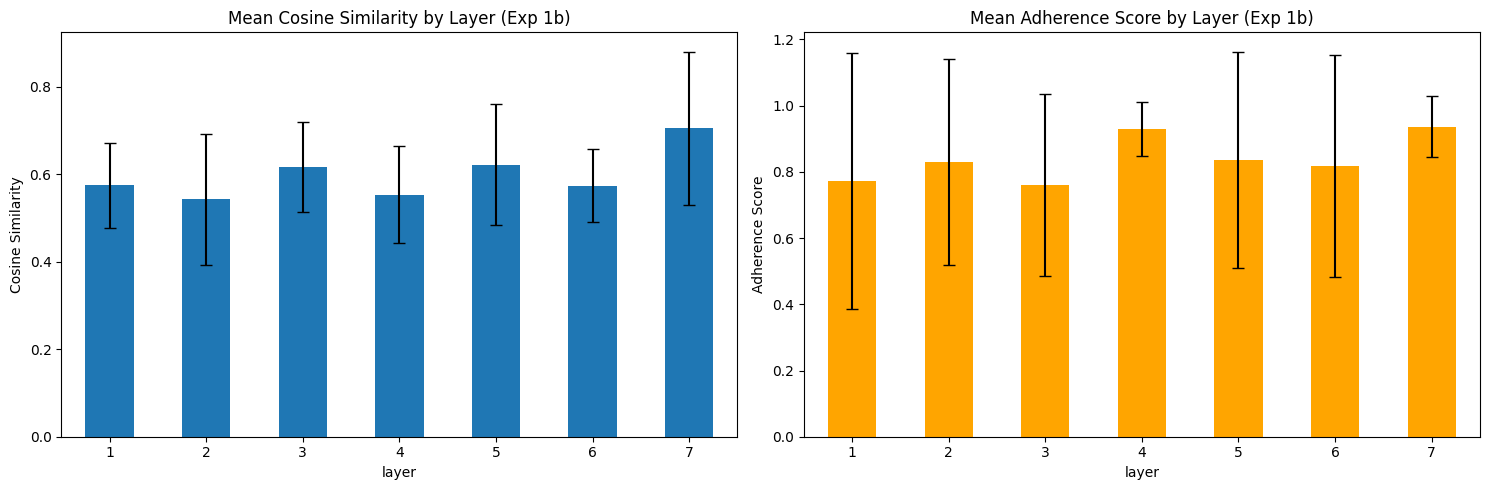

In [94]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plots['exp1b_metrics_by_layer'] = fig
layer_metrics_1b[("cosine_similarity", "mean")].plot(kind='bar', yerr=layer_metrics_1b[("cosine_similarity", "std")], ax=ax[0], capsize=4)
ax[0].set_title("Mean Cosine Similarity by Layer (Exp 1b)")
ax[0].set_ylabel("Cosine Similarity")
ax[0].tick_params(axis='x', rotation=0)
layer_metrics_1b[("adherence_score", "mean")].plot(kind='bar', yerr=layer_metrics_1b[("adherence_score", "std")], ax=ax[1], capsize=4, color="orange")
ax[1].set_title("Mean Adherence Score by Layer (Exp 1b)")
ax[1].set_ylabel("Adherence Score")
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 2.5: Cosine Similarity: LLM vs Input Source

In [95]:
llm_vs_input_source_cos_sim_1b = pd.pivot_table(
    exp1b_df,
    values="cosine_similarity",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1b_cosine_sim_llm_vs_input_source"] = llm_vs_input_source_cos_sim_1b
display(llm_vs_input_source_cos_sim_1b)

,mean,std
input_source,script_manipulated,script_manipulated
llm,,
anthropic,0.639624,0.120503
deepseek,0.535659,0.120614
google,0.618493,0.155956
openai,0.599776,0.107091


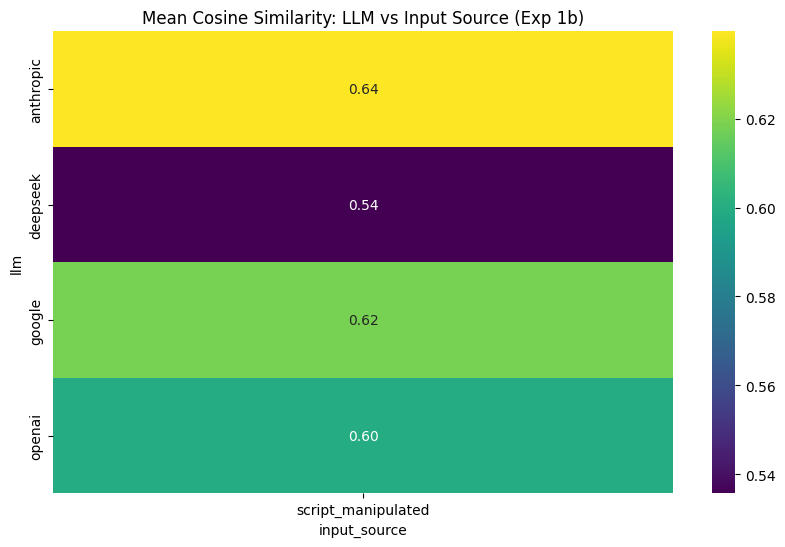

In [96]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1b_cosine_sim_llm_vs_input_source'] = fig
sns.heatmap(llm_vs_input_source_cos_sim_1b["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Cosine Similarity: LLM vs Input Source (Exp 1b)")
plt.show()


### 2.6: Cosine Similarity: LLM vs Prompt Type

In [97]:
llm_vs_prompt_type_cos_sim_1b = pd.pivot_table(
    exp1b_df,
    values="cosine_similarity",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1b_cosine_sim_llm_vs_prompt_type"] = llm_vs_prompt_type_cos_sim_1b
display(llm_vs_prompt_type_cos_sim_1b)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.702068  0.577180  0.139379  0.054194
deepseek     0.532872  0.538446  0.123492  0.127482
google       0.648236  0.588749  0.150385  0.167388
openai       0.601861  0.597690  0.100315  0.121553

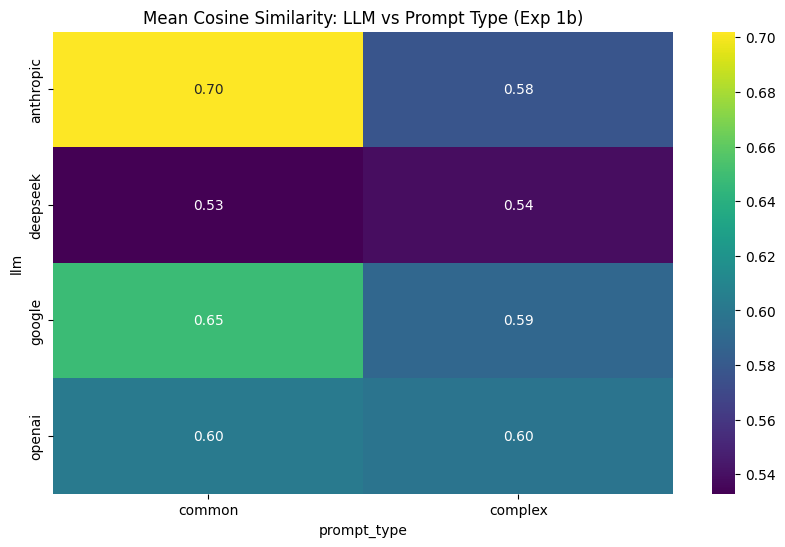

In [98]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1b_cosine_sim_llm_vs_prompt_type'] = fig
sns.heatmap(llm_vs_prompt_type_cos_sim_1b["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Cosine Similarity: LLM vs Prompt Type (Exp 1b)")
plt.show()


### 2.7: Adherence Score: LLM vs Prompt Type

In [99]:
llm_vs_prompt_type_adherence_1b = pd.pivot_table(
    exp1b_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1b_adherence_llm_vs_prompt_type"] = llm_vs_prompt_type_adherence_1b
display(llm_vs_prompt_type_adherence_1b)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.950000  0.857143  0.101036  0.132817
deepseek     0.864286  0.597857  0.326553  0.355585
google       0.997857  0.842857  0.005669  0.173850
openai       0.992857  0.619286  0.018898  0.444339

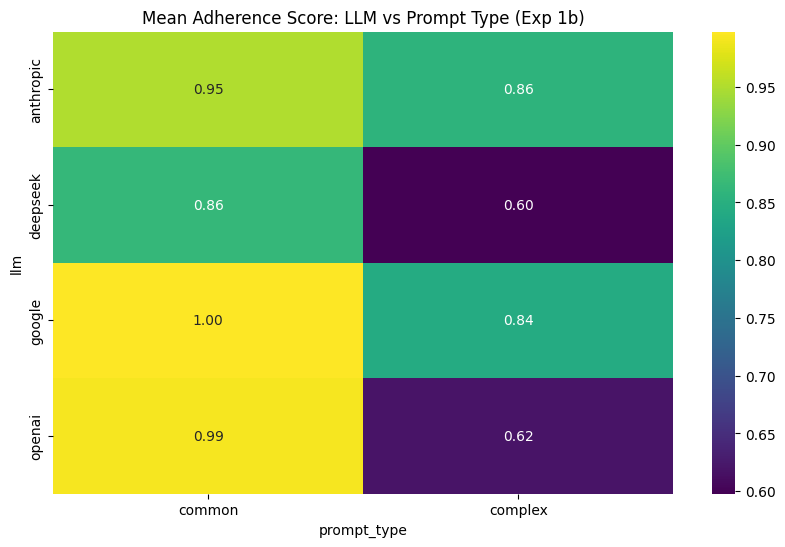

In [100]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1b_adherence_llm_vs_prompt_type'] = fig
sns.heatmap(llm_vs_prompt_type_adherence_1b["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Adherence Score: LLM vs Prompt Type (Exp 1b)")
plt.show()


### 2.8: Adherence Score: LLM vs Input Source

In [101]:
llm_vs_input_source_adherence_1b = pd.pivot_table(
    exp1b_df,
    values="adherence_score",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1b_adherence_llm_vs_input_source"] = llm_vs_input_source_adherence_1b
display(llm_vs_input_source_adherence_1b)

,mean,std
input_source,script_manipulated,script_manipulated
llm,,
anthropic,0.903571,0.123186
deepseek,0.731071,0.355929
google,0.920357,0.142942
openai,0.806071,0.358974


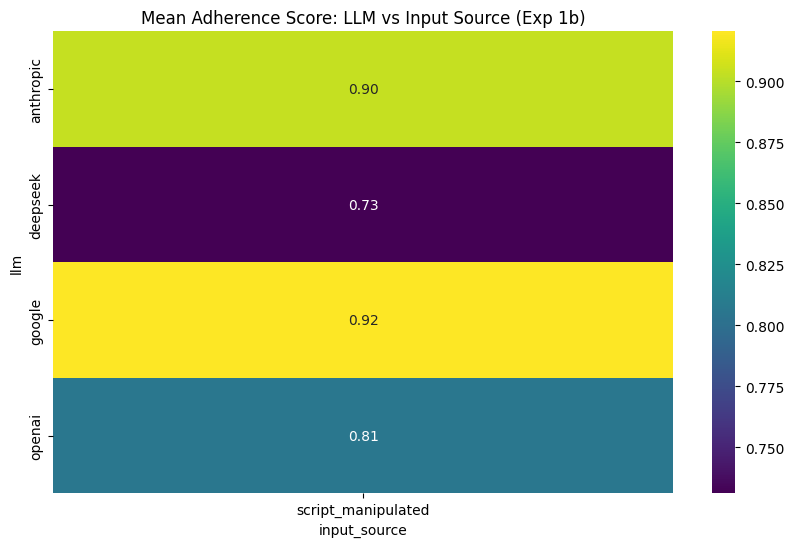

In [102]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1b_adherence_llm_vs_input_source'] = fig
sns.heatmap(llm_vs_input_source_adherence_1b["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Adherence Score: LLM vs Input Source (Exp 1b)")
plt.show()


## Save all tables and plots

In [103]:
def save_all_tables_and_plots():
    # Save tables
    for name, df in tables.items():
        if name.startswith("exp1a"):
            output_dir = output_dir_exp1a
            table_name = name.replace("exp1a_", "")
        elif name.startswith("exp1b"):
            output_dir = output_dir_exp1b
            table_name = name.replace("exp1b_", "")
        else:
            continue

        base_filename = os.path.join(output_dir, table_name)
        
        # Save to CSV
        csv_path = f"{base_filename}.csv"
        df.to_csv(csv_path)
        print(f"Saved {csv_path}")

    # Save plots
    for name, fig in plots.items():
        if name.startswith("exp1a"):
            output_dir = output_plot_dir_exp1a
            plot_name = name.replace("exp1a_", "")
        elif name.startswith("exp1b"):
            output_dir = output_plot_dir_exp1b
            plot_name = name.replace("exp1b_", "")
        else:
            continue
        
        base_filename = os.path.join(output_dir, plot_name)
        
        # Save to PNG
        png_path = f"{base_filename}.png"
        fig.savefig(png_path, bbox_inches='tight')
        print(f"Saved {png_path}")

save_all_tables_and_plots()

Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_llm.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_layer.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/cosine_sim_llm_vs_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/cosine_sim_llm_vs_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/adherence_llm_vs_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/adherence_llm_vs_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1b/metrics_by_llm.csv
Sav